# 1. Load dataloaders

In [ ]:
from data.dataloader import create_tremor_dataloaders

train_loader, val_loader = create_tremor_dataloaders(
    data_path="../project_datasets/tremor/movements",
    batch_size= 32,
    print_details=False,
    split_by_subject=True
)

# 2. Create models

In [ ]:
from Models.model_V11 import TremorClassifier

model = TremorClassifier()
model_name = "Tremor_Model"

# 3. Train models

In [ ]:
from training.trainer import train

train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    
    model_name=model_name,
    run_name=model_name,
    
    load_pretrained="checkpoints/model_11/Model_V11_BEST.pth",
    checkpoint_dir="checkpoints/",
    
    max_lr=5e-5,
    
    per_movement =False,
    debug_mode= False)

In [ ]:
# !tensorboard --logdir=runs

In [13]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load model
checkpoint = torch.load("checkpoints/Tremor_Model_BEST.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Loaded pretrained model:")
print(f"- val_loss={checkpoint['val_loss']:.4f}")
print(f"- balanced_accuracy={checkpoint['balanced_accuracy']:.4f}")
print(f"- macro_f1={checkpoint['macro_f1']:.4f}")

Loaded pretrained model:
- val_loss=0.7407
- balanced_accuracy=0.6343
- macro_f1=0.6140


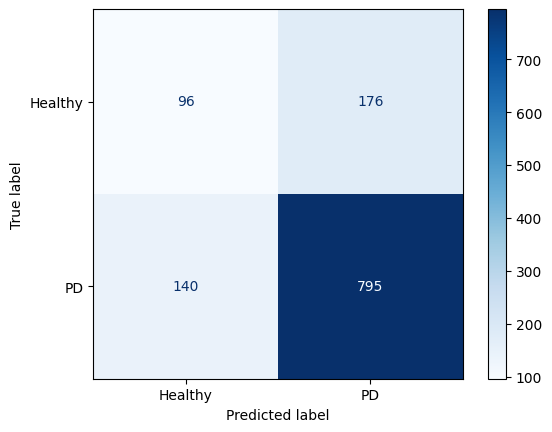

In [21]:
from training.confusion_mat import plot_confusion_matrix

plot_confusion_matrix(
    model=model,
    dataloader=val_loader,
    device="cuda",
    class_names=["Healthy", "PD"],
    threshold=0.4,
)